In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#implemetation for add gate
input_data = np.array([[0, 0, 0],
                       [0, 0, 1],
                       [0, 1, 0],
                       [0, 1, 1],
                       [1, 0, 0],
                       [1, 0, 1],
                       [1, 1, 0],
                       [1, 1, 1]])

target = np.array([[0],[1],[1],[1],[1],[1],[1],[1]])

In [3]:
# random weights
weights = np.array([1, 0, 0.5])

# Bias
bias = 0.1

# learning rate
eta = 0.1

# no. of epochs
epochs = 50

# no. of samples
num_samples = input_data.shape[0]

# error
error = np.zeros((num_samples, 1))

# MSE
mse = np.zeros((epochs, 1))

In [5]:
def threshold_activation(x):
  return 1 if x > 1 else 0

In [6]:
def perceptron_neuron(input_data, weights, bias):
    # Perform the weighted sum of inputs
    weighted_sum = np.dot(input_data, weights) + bias

    output = threshold_activation(weighted_sum)

    return output

In [7]:
def perceptron_update(input_data, target, output, weights, bias):
    if target == output:
        dw = np.zeros(weights.shape)
        weights = weights + dw
    else:
        dw = eta * input_data * target
        weights = weights + dw

        db = eta * target
        bias = bias + db

    return weights, bias

In [8]:
# Initialize an empty list to store the outputs
for i in range(epochs):
    print(f'\n ***** STARTING EPOCH {i} *******\n')
    for j in range(num_samples):
        output = perceptron_neuron(input_data[j,:], weights.T, bias)
        print(f'Output = {output}')

        error[j, 0] = target[j, 0] - output

        weights,bias = perceptron_update(input_data[j,:], target[j,:], output, weights, bias)
        print(f'New Weights ={weights}, New Bias={bias}, Target={target[j]}\n')

    mse[i, 0] = np.mean(pow(error,2))
    print(f"MSE of Epoch {i} = {mse[i, 0]}")


 ***** STARTING EPOCH 0 *******

Output = 0
New Weights =[1.  0.  0.5], New Bias=0.1, Target=[0]

Output = 0
New Weights =[1.  0.  0.6], New Bias=[0.2], Target=[1]

Output = 0
New Weights =[1.  0.1 0.6], New Bias=[0.3], Target=[1]

Output = 0
New Weights =[1.  0.2 0.7], New Bias=[0.4], Target=[1]

Output = 1
New Weights =[1.  0.2 0.7], New Bias=[0.4], Target=[1]

Output = 1
New Weights =[1.  0.2 0.7], New Bias=[0.4], Target=[1]

Output = 1
New Weights =[1.  0.2 0.7], New Bias=[0.4], Target=[1]

Output = 1
New Weights =[1.  0.2 0.7], New Bias=[0.4], Target=[1]

MSE of Epoch 0 = 0.375

 ***** STARTING EPOCH 1 *******

Output = 0
New Weights =[1.  0.2 0.7], New Bias=[0.4], Target=[0]

Output = 1
New Weights =[1.  0.2 0.7], New Bias=[0.4], Target=[1]

Output = 0
New Weights =[1.  0.3 0.7], New Bias=[0.5], Target=[1]

Output = 1
New Weights =[1.  0.3 0.7], New Bias=[0.5], Target=[1]

Output = 1
New Weights =[1.  0.3 0.7], New Bias=[0.5], Target=[1]

Output = 1
New Weights =[1.  0.3 0.7], N

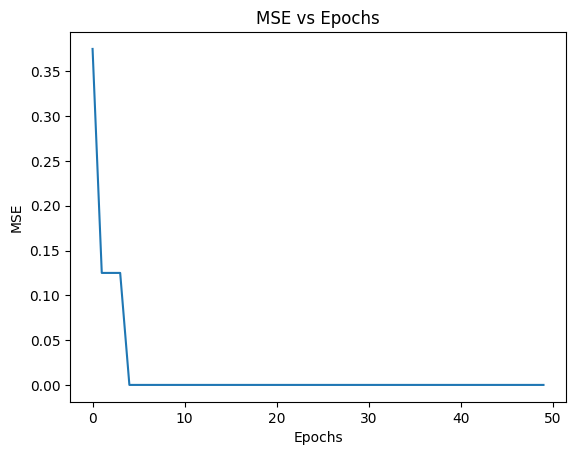

In [9]:
plt.plot(mse)
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.title('MSE vs Epochs')
plt.show()